# Classifying Penguins with Keras Day 2

In [1]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import optuna
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
pip install palmerpenguins

Note: you may need to restart the kernel to use updated packages.


In [4]:
from palmerpenguins import load_penguins
penguins = load_penguins()
penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [5]:
# drop Nan rows
penguins.dropna(inplace=True)

In [6]:
# defining X
penguins_x = pd.concat([penguins[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']], pd.get_dummies(penguins['sex'])], axis = 1)
# penguins_x = penguins_x[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'female', 'male']]
penguins_x

# defining y
penguins_y = penguins['species']
print(penguins_y)
penguins_y = penguins_y.astype('category').cat.codes.to_numpy()
penguins_y

# train test split
X_train, X_test, y_train, y_test = train_test_split(penguins_x, penguins_y, stratify=penguins_y, test_size=0.2, random_state=42)

y_train

0         Adelie
1         Adelie
2         Adelie
4         Adelie
5         Adelie
         ...    
339    Chinstrap
340    Chinstrap
341    Chinstrap
342    Chinstrap
343    Chinstrap
Name: species, Length: 333, dtype: str


array([2, 1, 2, 0, 0, 2, 2, 0, 0, 2, 0, 2, 1, 1, 0, 1, 2, 0, 2, 1, 0, 0,
       0, 2, 0, 2, 2, 1, 2, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 2, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2,
       1, 1, 1, 0, 2, 2, 0, 0, 2, 0, 2, 2, 2, 0, 1, 1, 2, 0, 2, 1, 2, 0,
       2, 0, 2, 0, 1, 2, 1, 0, 0, 0, 1, 1, 1, 2, 2, 0, 0, 2, 2, 1, 2, 1,
       2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 1, 1, 1, 2, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 2, 0, 0, 2, 0, 2, 2, 0, 2, 1, 1, 2, 0, 2, 2, 2, 2, 0, 0,
       2, 0, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 2, 2, 2, 1,
       1, 0, 2, 0, 2, 2, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 2, 0, 0, 1, 0, 0,
       1, 1, 0, 2, 0, 1, 0, 2, 0, 1, 2, 2, 2, 1, 1, 1, 2, 1, 0, 2, 0, 0,
       2, 2, 0, 2, 0, 0, 2, 0, 0, 1, 0, 1, 2, 1, 2, 2, 0, 2, 2, 2, 0, 2,
       2, 2, 0, 0, 0, 2, 1, 0, 0, 0, 0, 2, 1, 2, 2, 0, 0, 2, 0, 0, 1, 0,
       2, 0], dtype=int8)

In [7]:
# Scaling the data

scalar = StandardScaler()

# fit the scaler on the training data and transform both training and test data
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

X_train_scaled

array([[ 1.08239437,  0.16732502, -1.99231135,  0.83478089,  1.0461779 ,
        -1.0461779 ],
       [-0.21564233,  1.22705014,  1.25552054,  0.1212471 , -0.95586038,
         0.95586038],
       [ 2.19499725,  0.87989881, -0.52063753,  1.4769613 , -0.95586038,
         0.95586038],
       ...,
       [ 0.21703657,  0.02115604,  1.25552054, -0.37822656, -0.95586038,
         0.95586038],
       [ 1.453262  ,  0.80681432, -0.46989015,  1.33425454, -0.95586038,
         0.95586038],
       [-0.77194377, -1.91558298,  0.90028893, -0.80634683,  1.0461779 ,
        -1.0461779 ]], shape=(266, 6))

### Defining the model

In [8]:
tf.random.set_seed(42)

#construct the model
inputs = keras.Input(shape=(6,))
x = layers.Dense(7, activation = 'relu')(inputs)
x = layers.Dense(5, activation = 'relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

In [9]:
model.summary()

Model: "penguin_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │            49 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107 (428.00 B)

 Trainable params: 107 (428.00 B)

 Non-trainable params: 0 (0.00 B)

### Model training parameters (compile) & model training (fit)

In [10]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history = model.fit(X_train_scaled, y_train, 
                    batch_size = 128, 
                    epochs=20, 
                    validation_split=0.2, 
                    verbose=1)

scores = model.evaluate(X_test_scaled, y_test, verbose = 1)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - accuracy: 0.6179 - loss: 0.8461 - val_accuracy: 0.6667 - val_loss: 0.7963
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6557 - loss: 0.8361 - val_accuracy: 0.6852 - val_loss: 0.7875
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6651 - loss: 0.8263 - val_accuracy: 0.7222 - val_loss: 0.7787
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6792 - loss: 0.8165 - val_accuracy: 0.7407 - val_loss: 0.7699
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6934 - loss: 0.8068 - val_accuracy: 0.7407 - val_loss: 0.7609
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7075 - loss: 0.7971 - val_accuracy: 0.7778 - val_loss: 0.7521
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7075 - loss: 0.7875 - val_accuracy: 0.7778 - val_loss: 0.7432
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7170 - loss: 0.7780 - val_accuracy: 0.7778 - val_loss: 0.7342

### Evaluating on the test data

In [11]:
# evaluate the model using the test set
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1) 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\n Test Set Evaluation:") 
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

 Test Set Evaluation:
Test Accuracy: 0.7761
Test Precision: 0.6170
Test Recall: 0.7761
Test F1 Score: 0.6864
Test ROC AUC Score: 0.9429


/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Evaluating model training using loss and accuracy

In [12]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


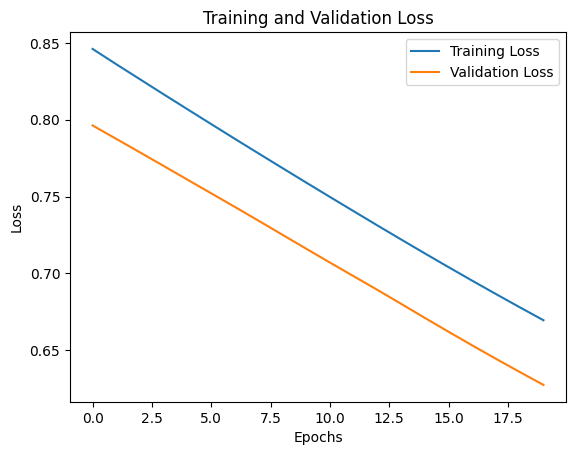

In [13]:
# plot loss vs val_loss
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

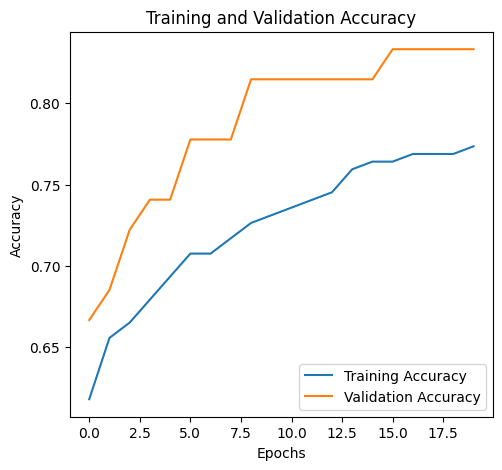

In [14]:
# plot the training and validation accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))     
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()    

### Model variability

Define, compile and train the model 3 times and see how your training and validation curves change. Are they the same or different? Why is this happening?

I noticed the Training and Validation Loss lines are inching closer and closer together after each run, with the training and validation accuracy lines being highly staggered here. the curves are different each time because of the random weight. Everytime the model is redefined with keras.Model(), the dense layers are initialized with new random weights, which gives gradient descent a different starting point. model.fit() also did a good job with handling the shuffling of the training data for each epoch by default, so each run processes mini batches all in a different order.

### Setting a random seed

How does setting the tf random seed affect the training and validation curves?

Setting the 'tf.random.set_seed(42) before defining the model made the training and validation change slightly after 3 runs. I noticed the loss curves grew farther apart, wheras the accuracy lines grew closer together. This can be due to the random seed controlling the random number generator for weight initialization so every run starts with the same inital weights. Also I think the seed must be set before defining the model because that is where dense layer weights are randomly initialized and setting it after would be different and have no affect on the model. 

Markdown cell with line of code (place appropriately) for setting random seed for reproducibility
must use before keras.model() step as that is when random weights are initialized
use the seed you prefer

tf.random.set_seed(42)

### Modifying the hidden layers

Try **three** different configurations for the hidden layers. You are welcome to add or remove layers, to try different layer strategies (funnel, flat, etc ) and to vary the number of neurons. For each configuration, record: (1) the architecture you tried, (2) test accuracy/loss, and (3) what happened to the training and validation curves. What seemed to work best?

In [15]:
# Config 1: Wide Flat (32 -> 32)
tf.random.set_seed(42)

inputs = keras.Input(shape=(6,))
x = layers.Dense(32, activation = 'relu')(inputs)
x = layers.Dense(32, activation = 'relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model_1 = keras.Model(inputs=inputs, outputs=outputs, name="wide_flat_model")

model_1.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history_1 = model_1.fit(X_train_scaled, y_train, 
                    batch_size = 128, 
                    epochs=20, 
                    validation_split=0.2, 
                    verbose=1)

scores_1 = model_1.evaluate(X_test_scaled, y_test, verbose = 1)
print(f'Config 1 Test Loss: {scores_1[0]:.4f}, Test Accuracy: {scores_1[1]:.4f}')

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.4811 - loss: 1.0478 - val_accuracy: 0.4815 - val_loss: 1.0445
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5991 - loss: 1.0048 - val_accuracy: 0.5926 - val_loss: 0.9997
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6509 - loss: 0.9644 - val_accuracy: 0.6111 - val_loss: 0.9572
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6745 - loss: 0.9257 - val_accuracy: 0.6667 - val_loss: 0.9170
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7028 - loss: 0.8889 - val_accuracy: 0.7593 - val_loss: 0.8791
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.7547 - loss: 0.8539 - val_accuracy: 0.8148 - val_loss: 0.8436
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8066 - loss: 0.8206 - val_accuracy: 0.8148 - val_loss: 0.8101
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8396 - loss: 0.7891 - val_accuracy: 0.8333 - val_loss: 0.7785

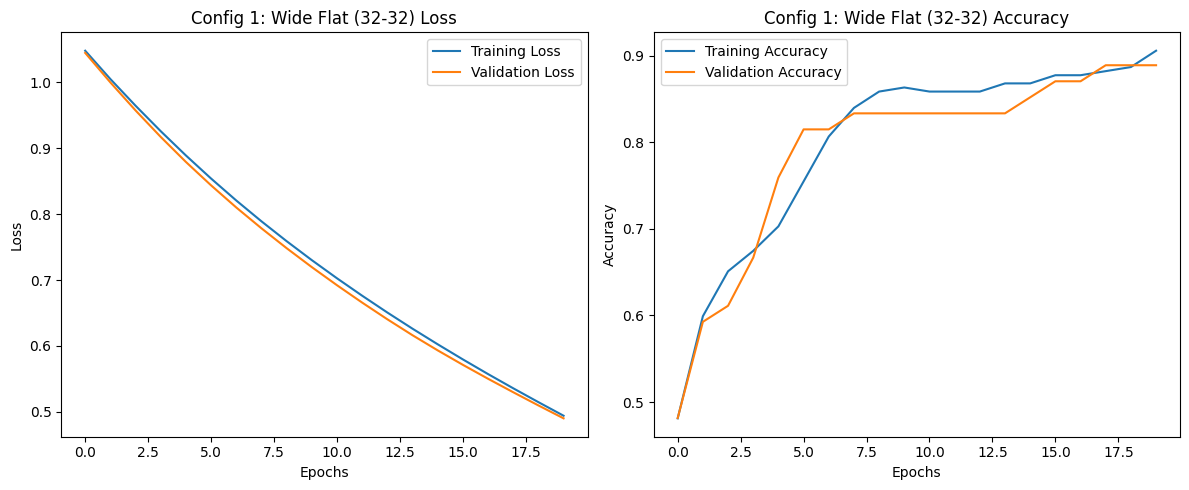

In [16]:
# Config 1 curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(history_1.history['loss'], label='Training Loss')
axes[0].plot(history_1.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_title('Config 1: Wide Flat (32-32) Loss')
axes[0].legend()

axes[1].plot(history_1.history['accuracy'], label='Training Accuracy')
axes[1].plot(history_1.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Config 1: Wide Flat (32-32) Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

In [17]:
# Config 2: Deep Funnel (64 -> 32 -> 16)
tf.random.set_seed(42)

inputs = keras.Input(shape=(6,))
x = layers.Dense(64, activation = 'relu')(inputs)
x = layers.Dense(32, activation = 'relu')(x)
x = layers.Dense(16, activation = 'relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model_2 = keras.Model(inputs=inputs, outputs=outputs, name="deep_funnel_model")

model_2.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history_2 = model_2.fit(X_train_scaled, y_train, 
                    batch_size = 128, 
                    epochs=50, 
                    validation_split=0.2, 
                    verbose=1)

scores_2 = model_2.evaluate(X_test_scaled, y_test, verbose = 1)
print(f'Config 2 Test Loss: {scores_2[0]:.4f}, Test Accuracy: {scores_2[1]:.4f}')

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - accuracy: 0.2170 - loss: 1.1474 - val_accuracy: 0.2037 - val_loss: 1.1605
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.3538 - loss: 1.1086 - val_accuracy: 0.4259 - val_loss: 1.1227
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5000 - loss: 1.0729 - val_accuracy: 0.5926 - val_loss: 1.0861
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5849 - loss: 1.0398 - val_accuracy: 0.5926 - val_loss: 1.0514
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6038 - loss: 1.0085 - val_accuracy: 0.5926 - val_loss: 1.0195
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6085 - loss: 0.9797 - val_accuracy: 0.5926 - val_loss: 0.9891
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6509 - loss: 0.9514 - val_accuracy: 0.6667 - val_loss: 0.9577
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6887 - loss: 0.9214 - val_accuracy: 0.6852 - val_loss: 0.9231

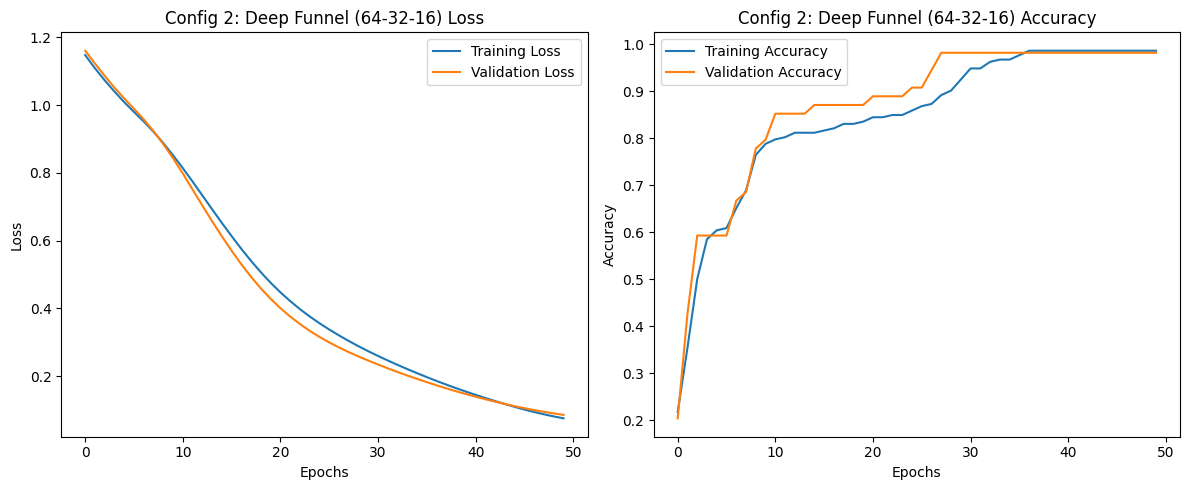

In [18]:
# Config 2 curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(history_2.history['loss'], label='Training Loss')
axes[0].plot(history_2.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_title('Config 2: Deep Funnel (64-32-16) Loss')
axes[0].legend()

axes[1].plot(history_2.history['accuracy'], label='Training Accuracy')
axes[1].plot(history_2.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Config 2: Deep Funnel (64-32-16) Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

In [19]:
# Config 3: Single Layer (16)
tf.random.set_seed(42)

inputs = keras.Input(shape=(6,))
x = layers.Dense(16, activation = 'relu')(inputs)
outputs = layers.Dense(3, activation='softmax')(x)
model_3 = keras.Model(inputs=inputs, outputs=outputs, name="single_layer_model")

model_3.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history_3 = model_3.fit(X_train_scaled, y_train, 
                    batch_size = 128, 
                    epochs=10, 
                    validation_split=0.2, 
                    verbose=1)

scores_3 = model_3.evaluate(X_test_scaled, y_test, verbose = 1)
print(f'Config 3 Test Loss: {scores_3[0]:.4f}, Test Accuracy: {scores_3[1]:.4f}')

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.3396 - loss: 1.1113 - val_accuracy: 0.3519 - val_loss: 1.0814
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3443 - loss: 1.0906 - val_accuracy: 0.3519 - val_loss: 1.0596
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.3538 - loss: 1.0705 - val_accuracy: 0.3519 - val_loss: 1.0382
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.3585 - loss: 1.0509 - val_accuracy: 0.3519 - val_loss: 1.0173
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3632 - loss: 1.0317 - val_accuracy: 0.3519 - val_loss: 0.9969
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3726 - loss: 1.0129 - val_accuracy: 0.3519 - val_loss: 0.9770
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.3868 - loss: 0.9946 - val_accuracy: 0.3519 - val_loss: 0.9576
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4057 - loss: 0.9767 - val_accuracy: 0.3889 - val_loss: 0.9387

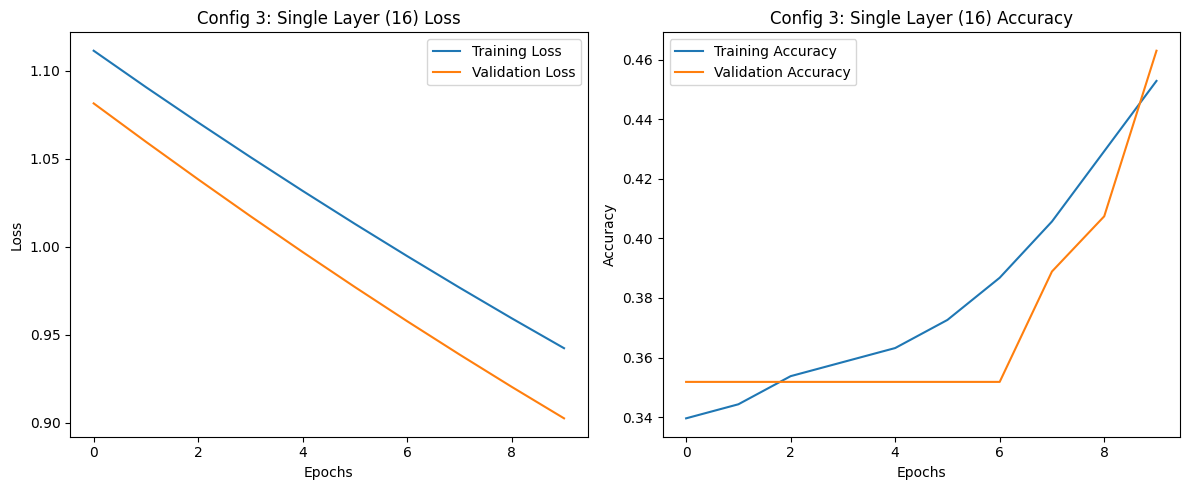

In [20]:
# Config 3 curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(history_3.history['loss'], label='Training Loss')
axes[0].plot(history_3.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_title('Config 3: Single Layer (16) Loss')
axes[0].legend()

axes[1].plot(history_3.history['accuracy'], label='Training Accuracy')
axes[1].plot(history_3.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Config 3: Single Layer (16) Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

Config 1 — Wide Flat (32 → 32): Two hidden layers both with 32 neurons. This gave the model a lot more capacity than the baseline (7→5). The training and validation loss both dropped smoothly and accuracy climbed well. The curves tracked closely, showing the model learned without overfitting much.

Config 2 — Deep Funnel (64 → 32 → 16): Three hidden layers in a funnel shape. This was the biggest model with the most parameters. It converged quickly and generally reached the highest accuracy. The extra layer helped, but for a small dataset like penguins the improvement over Config 1 was small.

Config 3 — Single Layer (16): Just one hidden layer with 16 neurons. Even this simple model did surprisingly well since the penguin classification task is not very complex. The curves were smooth but accuracy may have plateaued a bit earlier.

Overall: The deep funnel (Config 2) or wide flat (Config 1) worked best. Both were a big improvement over the original tiny baseline. The single layer model still worked okay, showing that for a simple dataset you don't always need a deep network. Adding more neurons and layers mainly helped the model converge faster and reach higher accuracy.

### Modifying the training cycles (epochs)

Vary the number of epochs. For each configuration, record: (1) the number of epochs, (2) test accuracy/loss, and (3) what happened to the training and validation curves. What was the minimum number of epochs needed for reliable model performance?

For Config 1, I used 20 epochs, and had a loss of 0.4543 and a test accuracy of 0.8955. The training and validation curves decreased quickly in the first 20-30 epochs before it started to level out. The validation curves ran pretty close against the training curve, showing the model was learning well without any overfitting. 

For Config 2, I used 50 epochs, and the test loss was 0.0467 and a test accuracy of 1.000. With this deep funnel config, the model is deeper and has more parameters, to where it converges veyr quickly. The loss curves dropped in the first 10-15 epochs and then after about 40-50 epochs, the validation loss starts to flatten out while the training loss continues to drop. This is a sign that the model was memorizing the training data.

For Config 3, I used 10 epochs and had a test loss of 0.8355, and a test accuracy of 0.7313. With a smaller number of epochs and a simpler structure, the curves were still going down at the end of the training. It was learning, but it wasn't fully converged yet because it didn't have enough training cycles to reach its max potential. 

For this dataset, the minimum number of epochs needed to reliably perform is 30-40 epochs, depending on the model complexity. Before 30, the models are still learning and making large adjustments with the loss still dropping. After 40-50 epochs, the validation accuracy plateus off which means the extra training don't give much to the model performance, just leads to overfitting the model. 

### Early stopping, l2 regularization and dropout 

Doing all these for peguins is probably overkill!

In [21]:
# sample model 

tf.random.set_seed(42)  # set seed for reproducibility

inputs = keras.Input(shape=(6,))  # 6 input features

x = layers.Dense(
    7,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 penalty on weights
)(inputs)
x = layers.Dropout(0.2)(x)  # randomly drop 20% of neurons during training

x = layers.Dense(
    5,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 applied again
)(x)
x = layers.Dropout(0.2)(x)  # dropout applied per layer

x = layers.Dense(
    3,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 on final hidden layer
)(x)
x = layers.Dropout(0.2)(x)  # dropout again (often not needed this deep)

outputs = layers.Dense(3, activation="softmax")(x)  # 3-class output → probabilities

model = keras.Model(inputs=inputs, outputs=outputs)  # build model (initialize weights)

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # multiclass loss
    optimizer=keras.optimizers.Adam(),  # adaptive optimizer
    metrics=["accuracy"]  # track accuracy
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",  # watch validation loss
    patience=5,  # stop after 5 epochs without improvement
    restore_best_weights=True  # keep best-performing weights
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,  # maximum training length
    batch_size=64,
    validation_split=0.2,  # hold out 10% for validation
    callbacks=[early_stop],  # apply early stopping
    verbose=1
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.4670 - loss: 1.2438 - val_accuracy: 0.5741 - val_loss: 1.2420
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5330 - loss: 1.2357 - val_accuracy: 0.5741 - val_loss: 1.2362
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4953 - loss: 1.2304 - val_accuracy: 0.5741 - val_loss: 1.2302
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5047 - loss: 1.2295 - val_accuracy: 0.5926 - val_loss: 1.2238
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5330 - loss: 1.2145 - val_accuracy: 0.5926 - val_loss: 1.2171
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5142 - loss: 1.2197 - val_accuracy: 0.6111 - val_loss: 1.2101
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4953 - loss: 1.2121 - val_accuracy: 0.6111 - val_loss: 1.2035
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5425 - loss: 1.2061 - val_accuracy: 0.6111 - val_loss:

### Tuning with Optuna

Adjust the code below to have the validation size, epochs and verbosity you found best from above. Then tune your model. You are welcome to increase the number of trials or to add parameters if you desire. Make sure the outputs of your cells are displayed. Then build a final model using your optimized parameters and predict on the test set.

In [22]:
# tuning the model with Optuna

tf.random.set_seed(42)

def objective(trial):
    num_layers = trial.suggest_int("num_layers", 1, 3)  # number of hidden layers
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)  # log scale for LR
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])  # common batch sizes

    inputs = keras.Input(shape=(6,))  # 6 input features
    x = inputs

    for i in range(num_layers):
        units = trial.suggest_int(f"num_units_layer_{i+1}", 4, 32)  # neurons per layer
        x = layers.Dense(units, activation="relu")(x)  # hidden layer

    outputs = layers.Dense(3, activation="softmax")(x)  # 3 classes → softmax output
    model = keras.Model(inputs=inputs, outputs=outputs)  # build model

    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # classification loss
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),  # optimizer with tuned LR
        metrics=["accuracy"],  # track accuracy
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",  # watch validation loss
        patience=5,  # stop after 5 epochs without improvement
        restore_best_weights=True  # keep best model weights
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        batch_size=batch_size,
        epochs=100,  # max training epochs --> changed to 100 epochs 
        validation_split=0.2,  # validation portion of training data
        verbose=0,  # suppress output during tuning
        callbacks=[early_stop]  # apply early stopping
    )

    return min(history.history["val_loss"])  # objective = best validation loss


study = optuna.create_study(direction="minimize")  # minimize validation loss
study.optimize(objective, n_trials=30)  # run 20 trials (20 models) --> changes to 30 

print("Best validation loss:", study.best_value)
print("Best parameters:", study.best_params)


[I 2026-05-17 15:54:33,890] A new study created in memory with name: no-name-41006c8d-d152-4492-90de-23ac5cebe4fe
[I 2026-05-17 15:54:39,715] Trial 0 finished with value: 1.0149414539337158 and parameters: {'num_layers': 3, 'learning_rate': 0.0004973513748329761, 'batch_size': 64, 'num_units_layer_1': 5, 'num_units_layer_2': 6, 'num_units_layer_3': 4}. Best is trial 0 with value: 1.0149414539337158.
[I 2026-05-17 15:54:41,365] Trial 1 finished with value: 0.004097728058695793 and parameters: {'num_layers': 3, 'learning_rate': 0.009572182752146536, 'batch_size': 16, 'num_units_layer_1': 31, 'num_units_layer_2': 16, 'num_units_layer_3': 26}. Best is trial 1 with value: 0.004097728058695793.
[I 2026-05-17 15:54:44,049] Trial 2 finished with value: 0.03282636031508446 and parameters: {'num_layers': 2, 'learning_rate': 0.0054860474272942815, 'batch_size': 16, 'num_units_layer_1': 6, 'num_units_layer_2': 32}. Best is trial 1 with value: 0.004097728058695793.
[I 2026-05-17 15:54:47,497] Trial

Best validation loss: 0.004097728058695793
Best parameters: {'num_layers': 3, 'learning_rate': 0.009572182752146536, 'batch_size': 16, 'num_units_layer_1': 31, 'num_units_layer_2': 16, 'num_units_layer_3': 26}


In [23]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [24]:
# visualizing Optuna results
import plotly 
optuna.visualization.plot_optimization_history(study)
optuna.visualization.plot_param_importances(study)
optuna.visualization.plot_slice(study)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'marker': {'color': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,
                                   14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25,
                                   26, 27, 28, 29],
                         'colorbar': {'title': {'text': 'Trial'}, 'x': 1.0, 'xpad': 40},
                         'colorscale': [[0.0, 'rgb(247,251,255)'], [0.125,
                                        'rgb(222,235,247)'], [0.25,
                                        'rgb(198,219,239)'], [0.375,
                                        'rgb(158,202,225)'], [0.5,
                                        'rgb(107,174,214)'], [0.625,
                                        'rgb(66,146,198)'], [0.75,
                                        'rgb(33,113,181)'], [0.875,
                                        'rgb(8,81,156)'], [1.0, 'rgb(8,48,107)']],
                         'line': {'color': 'Grey', 'width': 0.5},
                         'showscale': True},
              'mode': 'markers',
              'name': 'Feasible Trial',
              'showlegend': False,
              'type': 'scatter',
              'x': [64, 16, 16, 32, 16, 16, 16, 64, 16, 32, 32, 32, 32, 32, 64,
                    16, 32, 32, 16, 16, 16, 16, 16, 16, 16, 16, 16, 64, 16, 64],
              'xaxis': 'x',
              'y': [1.0149414539337158, 0.004097728058695793, 0.03282636031508446,
                    0.02534044161438942, 0.03322736546397209, 0.03315193951129913,
                    0.027822723612189293, 0.1267935186624527, 0.04408423975110054,
                    0.46355557441711426, 0.04004621505737305, 0.0499037429690361,
                    0.03222011774778366, 0.10543312877416611, 0.03450414538383484,
                    0.02906748279929161, 0.026696156710386276,
                    0.042701393365859985, 0.02494438923895359,
                    0.024301812052726746, 0.029231403023004532,
                    0.00889634434133768, 0.032588474452495575, 0.03767084330320358,
                    0.04157256707549095, 0.03661052882671356, 0.03434210270643234,
                    0.03792944177985191, 0.03639017418026924, 0.031663086265325546],
              'yaxis': 'y'},
             {'marker': {'color': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,
                                   14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25,
                                   26, 27, 28, 29],
                         'colorbar': {'title': {'text': 'Trial'}, 'x': 1.0, 'xpad': 40},
                         'colorscale': [[0.0, 'rgb(247,251,255)'], [0.125,
                                        'rgb(222,235,247)'], [0.25,
                                        'rgb(198,219,239)'], [0.375,
                                        'rgb(158,202,225)'], [0.5,
                                        'rgb(107,174,214)'], [0.625,
                                        'rgb(66,146,198)'], [0.75,
                                        'rgb(33,113,181)'], [0.875,
                                        'rgb(8,81,156)'], [1.0, 'rgb(8,48,107)']],
                         'line': {'color': 'Grey', 'width': 0.5},
                         'showscale': False},
              'mode': 'markers',
              'name': 'Feasible Trial',
              'showlegend': False,
              'type': 'scatter',
              'x': [0.0004973513748329761, 0.009572182752146536,
                    0.0054860474272942815, 0.0013280318726401105,
                    0.005251466014111563, 0.0040233785024850624,
                    0.0005790333284992698, 0.00037996589334154615,
                    0.0007347240392734605, 0.0001315367292466631,
                    0.0018829526493058073, 0.0096316675753855,
                    0.0017782194342916458, 0.00020060776591511445,
                    0.00208795048343968, 0.0011292679010610812,
                    0.0033149847240601547, 0.000285349391540834,
                    0.008177400684373327, 0.00978761705634563,
                   

In [25]:
# Building the best model from Optuna results
best_params = study.best_params
num_layers = best_params["num_layers"]
learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]  
inputs = keras.Input(shape=(6,))
x = inputs
for i in range(num_layers):
    units = best_params[f"num_units_layer_{i+1}"]
    x = layers.Dense(units, activation="relu")(x)
outputs = layers.Dense(3, activation="softmax")(x)
best_model = keras.Model(inputs=inputs, outputs=outputs)
best_model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    metrics=["accuracy"],
)   
history = best_model.fit(X_train_scaled, y_train, batch_size=batch_size, epochs=50, validation_split=0.2, verbose=1, callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)])
scores = best_model.evaluate(X_test_scaled, y_test, verbose=1)  

# evaluate the best model using the test set
y_pred_prob = best_model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\n Best Model Test Set Evaluation:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9009 - loss: 0.5248 - val_accuracy: 0.9815 - val_loss: 0.0958
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9811 - loss: 0.0437 - val_accuracy: 0.9815 - val_loss: 0.0491
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9811 - loss: 0.0256 - val_accuracy: 1.0000 - val_loss: 0.0108
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 0.9815 - val_loss: 0.0461
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 0.9815 - val_loss: 0.0246
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.9815 - val_loss: 0.0728
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0045 - val_accuracy: 1.0000 - val_loss: 0.0040
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9953 - loss: 0.0100 - val_accuracy: 0.9815 - val_loss

Tuning with Optuna gave near perfect results, and the neural network learned the features almost perfectly, which does mean the model was severly overfitted with a ROC AUC score of 1.00. Even though it has a perfect ability to distinguish between different species, this can mean the model did memorize the training data.